# Perudo — Bayesian Inference Walkthrough

In Perudo (Liar's Dice) each player hides five dice and players bid on the **total** count of a face across the whole table, *ones being wild*. The fun modelling problem isn't the rules — it's that **an opponent's bid is a signal about their hidden dice**.

This notebook builds up the bot's reasoning:

1. the naive **counting** baseline,
2. a **prior** over an opponent's hand,
3. a **likelihood** for their bids and the Bayesian **posterior**,
4. the resulting **informed** probability vs. the naive one,
5. **win rates** in self-play, and
6. **calibration** of the bot's probabilities.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from perudo.probability import unknown_match_pmf, match_probability
from perudo.bids import Bid
from perudo.inference import _enumerate, OpponentBelief, BayesianAgent
from perudo.agents import CountingAgent, RandomAgent, PlayerView
from perudo.game import GameState
from perudo.simulate import head_to_head, collect_calibration, brier_score, reliability_curve

np.random.seed(0)
plt.rcParams['figure.figsize'] = (7, 4)

## 1. The counting baseline

If you ignore the bidding and treat every unseen die as fair, the number of dice matching a face is Binomial. A non-ace face is matched by that face *or* a wild ace, so $p = 2/6$; the aces face itself has $p = 1/6$.

$$P(\text{matches} = k \mid n\ \text{unseen}) = \binom{n}{k} p^k (1-p)^{n-k}.$$

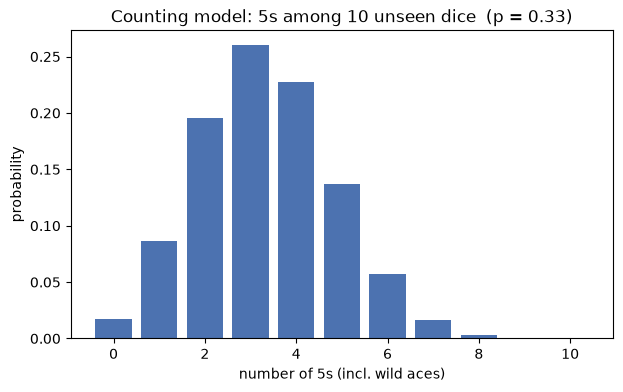

In [2]:
p = match_probability(5)
pmf = unknown_match_pmf(10, 5)
plt.bar(range(len(pmf)), pmf, color='#4c72b0')
plt.title(f'Counting model: 5s among 10 unseen dice  (p = {p:.2f})')
plt.xlabel('number of 5s (incl. wild aces)'); plt.ylabel('probability')
plt.show()

## 2. A prior over an opponent's hand

Summarise an opponent's hand of $m$ dice by its per-face count vector $c = (c_1,\dots,c_6)$ with $\sum_f c_f = m$. There are only $\binom{m+5}{5}$ of these (252 for $m=5$), so we enumerate them exactly. Under fair dice the prior is Multinomial:

$$P(c) = \frac{m!}{c_1!\cdots c_6!}\left(\tfrac{1}{6}\right)^m.$$

With no observations this must reproduce the binomial baseline above.

In [3]:
vectors, match_counts, prior = _enumerate(5)
print('count vectors for 5 dice:', len(vectors))
print('prior sums to', round(prior.sum(), 12))

belief = OpponentBelief(5, beta=1.0)
print('prior match-pmf equals the binomial:',
      np.allclose(belief.match_pmf(5), unknown_match_pmf(5, 5)))

count vectors for 5 dice: 252
prior sums to 1.0
prior match-pmf equals the binomial: True


## 3. Likelihood and the posterior update

Players tend to bid faces they actually hold. Model a bid of face $f$ as soft evidence with a softmax (noisy-rational) likelihood

$$P(\text{bid } f \mid c) \;\propto\; \exp\!\big(\beta \cdot \text{matches}(c, f)\big),$$

where $\beta$ is a rationality knob ($\beta = 0$ ignores bids; larger $\beta$ trusts them more). Bayes then gives
$P(c \mid \text{bid}) \propto P(c)\,P(\text{bid}\mid c)$, applied once per observed bid. Watch the posterior over the opponent's 5s shift as they keep bidding 5s.

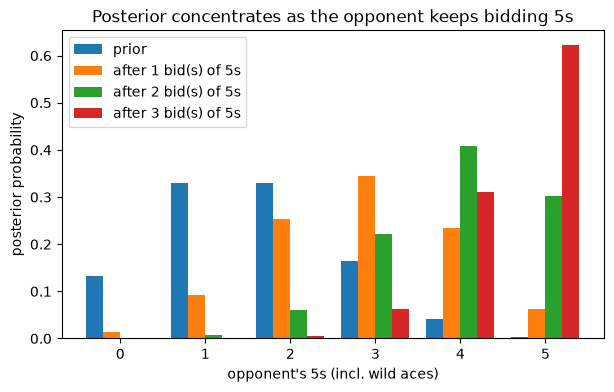

expected 5s — prior 1.67, after 3 bids 4.55


In [4]:
belief = OpponentBelief(5, beta=1.0)
stages = {'prior': belief.match_pmf(5).copy()}
for k in (1, 2, 3):
    belief.update(5)
    stages[f'after {k} bid(s) of 5s'] = belief.match_pmf(5).copy()

x = np.arange(6); w = 0.2
for i, (label, pmf) in enumerate(stages.items()):
    plt.bar(x + (i - 1.5) * w, pmf, width=w, label=label)
plt.legend(); plt.xlabel("opponent's 5s (incl. wild aces)")
plt.ylabel('posterior probability')
plt.title('Posterior concentrates as the opponent keeps bidding 5s')
plt.show()

print('expected 5s — prior %.2f, after 3 bids %.2f'
      % (OpponentBelief(5, 1.0).expected_matches(5), belief.expected_matches(5)))

## 4. Informed vs. naive probability

Sum the opponents' posterior contributions (convolving their marginals — a mean-field independence approximation), add our own known dice, and we get an *informed* distribution of the table total. Below, an opponent has bid 5s three times and we hold no 5s: the Bayesian estimate of 'how many 5s are out there' sits well above the history-blind binomial.

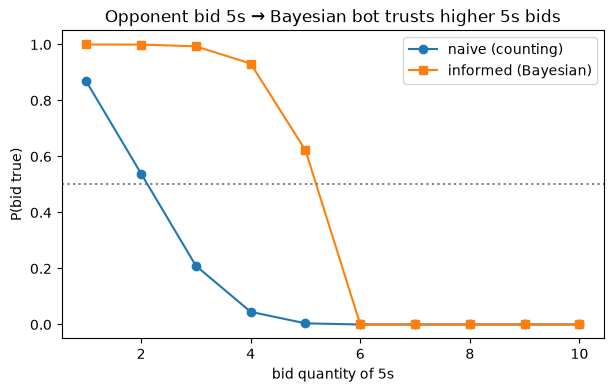

In [5]:
agent = BayesianAgent(beta=1.0)
gs = GameState(num_players=2, seed=0)
gs.dice_counts = [5, 5]; gs.hands = [(), (2, 3, 4, 6, 6)]; gs.current_player = 1
agent.observe_round_start(PlayerView.from_state(gs, 1))
for b in [Bid(2, 5), Bid(3, 5), Bid(4, 5)]:
    agent.observe_bid(0, b)
view = PlayerView.from_state(gs, 1)

qs = list(range(1, 11))
informed = [agent.informed_bid_probability(Bid(q, 5)) for q in qs]
naive = [agent.naive_bid_probability(view, Bid(q, 5)) for q in qs]
plt.plot(qs, naive, 'o-', label='naive (counting)')
plt.plot(qs, informed, 's-', label='informed (Bayesian)')
plt.axhline(0.5, ls=':', c='gray')
plt.xlabel('bid quantity of 5s'); plt.ylabel('P(bid true)')
plt.title('Opponent bid 5s → Bayesian bot trusts higher 5s bids')
plt.legend(); plt.show()

## 5. Does the inference win games?

Self-play with rotated seating (to cancel any first-mover edge). The Bayesian bot uses the *same* decision policy as the counting bot — the only difference is that it evaluates bids against the informed posterior.

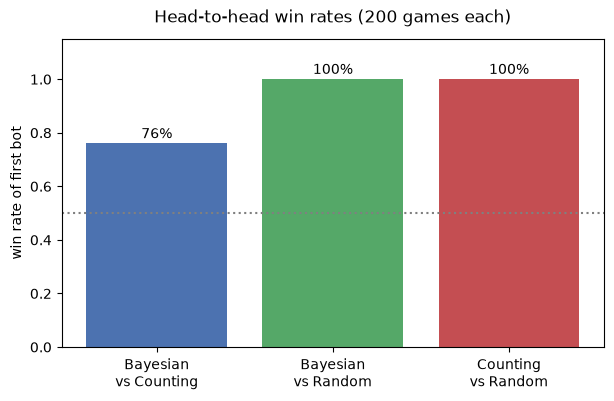

In [6]:
N = 200
b_vs_c = head_to_head(lambda: BayesianAgent('B'), lambda: CountingAgent('C'), N)
b_vs_r = head_to_head(lambda: BayesianAgent('B'), lambda: RandomAgent('R', seed=0), N)
c_vs_r = head_to_head(lambda: CountingAgent('C'), lambda: RandomAgent('R', seed=0), N)

labels = ['Bayesian\nvs Counting', 'Bayesian\nvs Random', 'Counting\nvs Random']
vals = [b_vs_c, b_vs_r, c_vs_r]
plt.bar(labels, vals, color=['#4c72b0', '#55a868', '#c44e52'])
plt.axhline(0.5, ls=':', c='gray'); plt.ylabel('win rate of first bot')
plt.title(f'Head-to-head win rates ({N} games each)', pad=12)
for i, v in enumerate(vals):
    plt.text(i, v + 0.02, f'{v:.0%}', ha='center')
plt.ylim(0, 1.15)  # headroom so value labels clear the title
plt.show()

## 6. Is the bot well-calibrated?

A good probabilistic player should be *calibrated*: bids it calls 70% likely should come true about 70% of the time. We log each Bayesian bid's predicted probability and its realised truth (read from the dice revealed at the next Dudo), then plot a reliability diagram and report the Brier score.

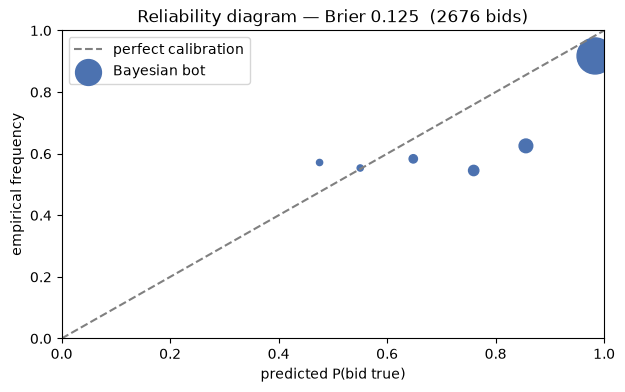

Brier score: 0.125  (0.25 = uninformative coin-flip)


In [7]:
records = collect_calibration(n_games=120, seed=1)
brier = brier_score(records)
rows = reliability_curve(records, n_bins=10)
mp = [r['mean_pred'] for r in rows]
ef = [r['emp_freq'] for r in rows]
cnt = [r['count'] for r in rows]

plt.plot([0, 1], [0, 1], '--', c='gray', label='perfect calibration')
plt.scatter(mp, ef, s=[max(20, c / 3) for c in cnt], c='#4c72b0', label='Bayesian bot')
plt.xlabel('predicted P(bid true)'); plt.ylabel('empirical frequency')
plt.title(f'Reliability diagram — Brier {brier:.3f}  ({len(records)} bids)')
plt.legend(); plt.xlim(0, 1); plt.ylim(0, 1); plt.show()
print(f'Brier score: {brier:.3f}  (0.25 = uninformative coin-flip)')

## 7. Takeaways and limitations

* Treating bids as signals and updating a posterior over hidden dice beats naive counting head-to-head, while staying well-calibrated (Brier well below 0.25).
* **Marker dot size = sample count.** The bot tends to be slightly *overconfident* in the upper-mid range — a natural target for tuning.

Modelling simplifications worth calling out:

* **Mean-field independence** across opponents (we keep per-opponent marginals and convolve) avoids the $252^k$ joint but ignores correlations.
* The **softmax likelihood** keys on the bid's *face*; it doesn't fully use the quantity or model bluffing/forced raises.
* $\beta$ is fixed; learning it (or per-opponent styles) and adding Calza/Palifico are natural extensions.
